In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_FIGURES = True 

PLOT_SINGLEPATCH = True
PLOT_NONORME = False
PLOT_PREFIX = False    
assert not (PLOT_SINGLEPATCH and PLOT_NONORME), "Cannot plot both Single-Patch and No norm curves together. Please set one of them to False."
assert not (PLOT_PREFIX and PLOT_NONORME), "Cannot plot both Prefix@8 and No norm curves together. Please set one of them to False."
assert not (PLOT_PREFIX and PLOT_SINGLEPATCH), "Cannot plot both Prefix@8 and Single-Patch curves together. Please set one of them to False."

MAX_STEP = 285_000

def ema(x, alpha=0.05):
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1-alpha) * out[i-1]
    return out

In [32]:
# causal + sinh^(-1)
df = pd.read_csv('../traininglosses/causalsinh.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_causalsinh = df["causalsinh - train_loss"].values

In [33]:
# causal
df = pd.read_csv('../traininglosses/causal.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_causal = df["causal - train_loss"].values

In [34]:
# vanilla
df = pd.read_csv('../traininglosses/vanilla.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_vanilla = df["vanilla - train_loss"].values

In [35]:
# vanilla + sinh^(-1)
df = pd.read_csv('../traininglosses/vanillasinh.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_vanillasinh = df["vanillasinh - train_loss"].values

In [36]:
# prefix@4
df = pd.read_csv('../traininglosses/prefix4.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix4 = df["prefix4falseV2 - train_loss"].values

In [37]:
# prefix@4 + sinh^(-1)
df = pd.read_csv('../traininglosses/prefix4sinh.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix4sinh = df["prefix4trueV2 - train_loss"].values

In [38]:
# prefix@8 + sinh^(-1)
df = pd.read_csv('../traininglosses/prefix8sinh.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix8sinh = df["prefix8trueV2 - train_loss"].values

In [39]:
# prefix@8
df = pd.read_csv('../traininglosses/prefix8.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix8 = df["prefix8falseV2 - train_loss"].values

In [40]:
# prefix@1 + sinh^(-1)
df = pd.read_csv('../traininglosses/prefix1sinh.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix1sinh = df["prefix1trueV2 - train_loss"].values

In [41]:
# prefix@1
df = pd.read_csv('../traininglosses/prefix1.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix1 = df["prefix1falseV2 - train_loss"].values

In [42]:
# singlepatch + sinh^(-1)
df = pd.read_csv('../traininglosses/singlepatchsinh.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_singlepatchsinh = df["singlepatchsinh - train_loss"].values

In [43]:
# singlepatch
df = pd.read_csv('../traininglosses/singlepatch.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_singlepatch = df["singlepatch - train_loss"].values

In [44]:
# none
df = pd.read_csv('../traininglosses/none.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_none = df["none - train_loss"].values

In [45]:
dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@4 RevIN":              "#FF3300",  # bright red-orange
    "Prefix@4 RevIN + asinh":      "#CC0099",  # strong magenta

    "No norm":                "#999999",  # medium gray
    "Single-Patch":                "#0E9594",  # cyan
    "Single-Patch + asinh":        "#7B2CBF",  # purple
    "Prefix@8 RevIN":              "#FF3300",  # bright red-orange
    "Prefix@8 RevIN + asinh":      "#CC0099",  # strong magenta
    "Prefix@1 RevIN":              "#FF3300",  # bright red-orange
    "Prefix@1 RevIN + asinh":      "#CC0099",  # strong magenta
}

dic_model_symbols = {
    "Causal RevIN":          "o",   # circle
    "Causal RevIN + asinh":  "x",   # cross
    "RevIN":                 "s",   # square
    "RevIN + asinh":         "d",   # diamond
    "Prefix@4 RevIN":              "^",   # triangle up
    "Prefix@4 RevIN + asinh":      "v",   # triangle down
    "Prefix@1 RevIN":              "^",   # triangle up
    "Prefix@1 RevIN + asinh":      "v",   # triangle down
    "No norm":                "P",   # plus (filled)
    "Prefix@8 RevIN":              "^",   # triangle up
    "Prefix@8 RevIN + asinh":      "v",   # triangle down
    "Single-Patch":                "*",   # star
    "Single-Patch + asinh":        "D",   # diamond
}

In [46]:
x = np.linspace(0, MAX_STEP, len(train_loss_causal))

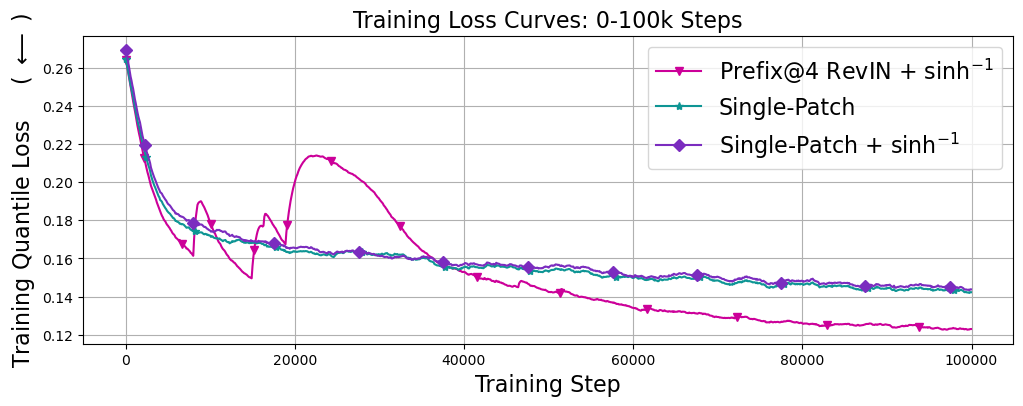

In [48]:
START, END = 0, 100_000
start_index = int(START / 285_000 * len(train_loss_causal))
end_index = int(END / 285_000 * len(train_loss_causal))


if PLOT_SINGLEPATCH:

    plt.figure(figsize=(12, 4))

    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1) 
    plt.plot(x[start_index:end_index], ema(train_loss_singlepatch)[start_index:end_index], label="Single-Patch", color=dic_model_colors["Single-Patch"], marker=dic_model_symbols["Single-Patch"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_singlepatchsinh)[start_index:end_index], label="Single-Patch + $\sinh^{-1}$", color=dic_model_colors["Single-Patch + asinh"], marker=dic_model_symbols["Single-Patch + asinh"], markevery=0.1)

elif PLOT_NONORME:

    plt.figure(figsize=(12, 4))

    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1) 
    plt.plot(x[start_index:end_index], ema(train_loss_none)[start_index:end_index], label="No norm", color=dic_model_colors["No norm"], marker=dic_model_symbols["No norm"], markevery=0.1)

else:

    plt.figure(figsize=(12, 6))

    plt.plot(x[start_index:end_index], ema(train_loss_causal)[start_index:end_index], label="Causal RevIN", color=dic_model_colors["Causal RevIN"], marker=dic_model_symbols["Causal RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_causalsinh)[start_index:end_index], label="Causal RevIN + $\sinh^{-1}$", color=dic_model_colors["Causal RevIN + asinh"], marker=dic_model_symbols["Causal RevIN + asinh"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_vanillasinh)[start_index:end_index], label="RevIN", color=dic_model_colors["RevIN"], marker=dic_model_symbols["RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_vanilla)[start_index:end_index], label="RevIN + $\sinh^{-1}$", color=dic_model_colors["RevIN + asinh"], marker=dic_model_symbols["RevIN + asinh"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix4)[start_index:end_index], label="Prefix@4 RevIN", color=dic_model_colors["Prefix@4 RevIN"], marker=dic_model_symbols["Prefix@4 RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1)  

plt.xlabel("Training Step", fontsize=16)
plt.ylabel("Training Quantile Loss     ( $\longleftarrow$ )", fontsize=16)
plt.title("Training Loss Curves: 0-100k Steps", fontsize=16)
plt.legend(fontsize=16)
plt.grid()

if SAVE_FIGURES and not PLOT_SINGLEPATCH and not PLOT_NONORME:
    plt.savefig("figures/training_loss_curves_0_100k.pdf", dpi=300, bbox_inches='tight')
elif SAVE_FIGURES and PLOT_SINGLEPATCH:
    plt.savefig("figures/singlepatch_training_loss_curves_0_100k.pdf", dpi=300, bbox_inches='tight')
elif SAVE_FIGURES and PLOT_NONORME:
    plt.savefig("figures/nonorm_training_loss_curves_0_100k.pdf", dpi=300, bbox_inches='tight')

plt.show()

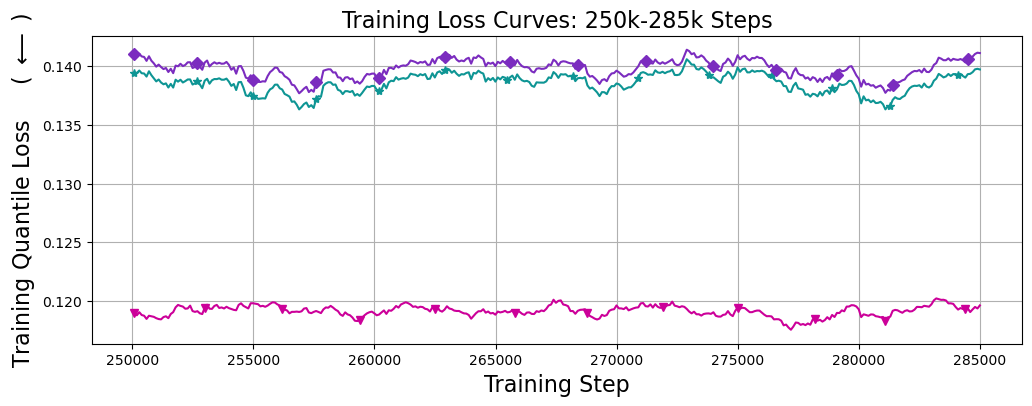

In [50]:
START, END = 250_000, 285_000
start_index = int(START / 285_000 * len(train_loss_causal))
end_index = int(END / 285_000 * len(train_loss_causal))


if PLOT_NONORME:

    plt.figure(figsize=(12, 4))

    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1) 
    plt.plot(x[start_index:end_index], ema(train_loss_none)[start_index:end_index], label="No norm", color=dic_model_colors["No norm"], marker=dic_model_symbols["No norm"], markevery=0.1)

elif PLOT_SINGLEPATCH:

    plt.figure(figsize=(12, 4))
    
    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1) 
    plt.plot(x[start_index:end_index], ema(train_loss_singlepatch)[start_index:end_index], label="Single-Patch", color=dic_model_colors["Single-Patch"], marker=dic_model_symbols["Single-Patch"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_singlepatchsinh)[start_index:end_index], label="Single-Patch + $\sinh^{-1}$", color=dic_model_colors["Single-Patch + asinh"], marker=dic_model_symbols["Single-Patch + asinh"], markevery=0.1) 

elif PLOT_PREFIX:
    
    plt.figure(figsize=(12, 4))

    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1) 
    plt.plot(x[start_index:end_index], ema(train_loss_prefix8sinh)[start_index:end_index], label="Prefix@8 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@8 RevIN + asinh"], marker=dic_model_symbols["Prefix@8 RevIN + asinh"], markevery=0.1) 
    plt.plot(x[start_index:end_index], ema(train_loss_prefix1sinh)[start_index:end_index], label="Prefix@1 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@1 RevIN + asinh"], marker=dic_model_symbols["Prefix@1 RevIN + asinh"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix4)[start_index:end_index], label="Prefix@4 RevIN", color=dic_model_colors["Prefix@4 RevIN"], marker=dic_model_symbols["Prefix@4 RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix8)[start_index:end_index], label="Prefix@8 RevIN", color=dic_model_colors["Prefix@8 RevIN"], marker=dic_model_symbols["Prefix@8 RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix1)[start_index:end_index], label="Prefix@1 RevIN", color=dic_model_colors["Prefix@1 RevIN"], marker=dic_model_symbols["Prefix@1 RevIN"], markevery=0.1)

else:

    plt.figure(figsize=(12, 6))

    plt.plot(x[start_index:end_index], ema(train_loss_causal)[start_index:end_index], label="Causal RevIN", color=dic_model_colors["Causal RevIN"], marker=dic_model_symbols["Causal RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_causalsinh)[start_index:end_index], label="Causal RevIN + $\sinh^{-1}$", color=dic_model_colors["Causal RevIN + asinh"], marker=dic_model_symbols["Causal RevIN + asinh"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_vanillasinh)[start_index:end_index], label="RevIN", color=dic_model_colors["RevIN"], marker=dic_model_symbols["RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_vanilla)[start_index:end_index], label="RevIN + $\sinh^{-1}$", color=dic_model_colors["RevIN + asinh"], marker=dic_model_symbols["RevIN + asinh"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix4)[start_index:end_index], label="Prefix@4 RevIN", color=dic_model_colors["Prefix@4 RevIN"], marker=dic_model_symbols["Prefix@4 RevIN"], markevery=0.1)
    plt.plot(x[start_index:end_index], ema(train_loss_prefix4sinh)[start_index:end_index], label="Prefix@4 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@4 RevIN + asinh"], marker=dic_model_symbols["Prefix@4 RevIN + asinh"], markevery=0.1)  

plt.xlabel("Training Step", fontsize=16)
plt.ylabel("Training Quantile Loss     ( $\longleftarrow$ )", fontsize=16)
plt.title("Training Loss Curves: 250k-285k Steps", fontsize=16)

#plt.legend()
plt.grid()
if SAVE_FIGURES and not PLOT_NONORME and not PLOT_SINGLEPATCH:
    plt.savefig("figures/training_loss_curves_250k_285k.pdf", dpi=300, bbox_inches='tight')
elif SAVE_FIGURES and PLOT_NONORME:
    plt.savefig("figures/nonorm_training_loss_curves_250k_285k.pdf", dpi=300, bbox_inches='tight')
elif SAVE_FIGURES and PLOT_SINGLEPATCH:
    plt.savefig("figures/singlepatch_training_loss_curves_250k_285k.pdf", dpi=300, bbox_inches='tight')
plt.show()